In [21]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Activation, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import imagenet_utils
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix
import itertools
import os
import shutil
from sklearn import metrics
import random
import matplotlib.pyplot as plt
%matplotlib inline

In [22]:
train_path = "C:\\Users\\Dell\\Desktop\\Dataset\\Train"
valid_path = "C:\\Users\\Dell\\Desktop\\Dataset\\Validation"
test_path = "C:\\Users\\Dell\\Desktop\\Dataset\\Test"

train_batches = ImageDataGenerator(preprocessing_function=tf.keras.applications.mobilenet.preprocess_input).flow_from_directory(
    directory=train_path, classes = ['BabyCry', 'Bark', 'Cough', 'Dishes', 'Doorbell', 'FireAlarm', 'SmokeDetector', 'Sneeze', 'Thunder', 'Water'], target_size=(224,224), batch_size=32)
valid_batches = ImageDataGenerator(preprocessing_function=tf.keras.applications.mobilenet.preprocess_input).flow_from_directory(
    directory=valid_path, classes = ['BabyCry', 'Bark', 'Cough', 'Dishes', 'Doorbell', 'FireAlarm', 'SmokeDetector', 'Sneeze', 'Thunder', 'Water'], target_size=(224,224), batch_size=32)
test_batches = ImageDataGenerator(preprocessing_function=tf.keras.applications.mobilenet.preprocess_input).flow_from_directory(
    directory=test_path, classes = ['BabyCry', 'Bark', 'Cough', 'Dishes', 'Doorbell', 'FireAlarm', 'SmokeDetector', 'Sneeze', 'Thunder', 'Water'], target_size=(224,224), batch_size=10, shuffle=False)

Found 4890 images belonging to 10 classes.
Found 524 images belonging to 10 classes.
Found 524 images belonging to 10 classes.


In [23]:
img, l = next(train_batches)
def plotImages(images):
    fig, axes = plt.subplots(1, 10, figsize = (20,20))
    axes = axes.flatten()
    for img, ax in zip(images,axes):
        ax.imshow(img)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

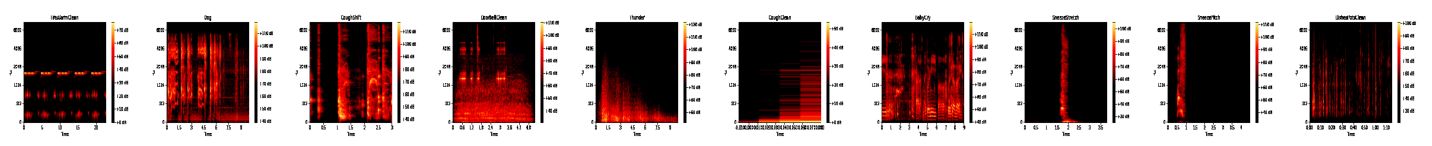

[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0.

In [24]:
plotImages(img)
print(l)

In [25]:
mobile = tf.keras.applications.mobilenet.MobileNet()
mobile.summary()

Model: "mobilenet_1.00_224"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 conv1 (Conv2D)              (None, 112, 112, 32)      864       
                                                                 
 conv1_bn (BatchNormalizatio  (None, 112, 112, 32)     128       
 n)                                                              
                                                                 
 conv1_relu (ReLU)           (None, 112, 112, 32)      0         
                                                                 
 conv_dw_1 (DepthwiseConv2D)  (None, 112, 112, 32)     288       
                                                                 
 conv_dw_1_bn (BatchNormaliz  (None, 112, 112, 32)     128       
 ation)                                         

In [26]:
model = Sequential()
for layer in mobile.layers[:-5]:
    model.add(layer)

In [27]:
for layer in model.layers[:-23]:
    layer.trainable = False

In [28]:
model.add(Flatten())
model.add(Dense(units = 10, activation = 'softmax'))

In [29]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1 (Conv2D)              (None, 112, 112, 32)      864       
                                                                 
 conv1_bn (BatchNormalizatio  (None, 112, 112, 32)     128       
 n)                                                              
                                                                 
 conv1_relu (ReLU)           (None, 112, 112, 32)      0         
                                                                 
 conv_dw_1 (DepthwiseConv2D)  (None, 112, 112, 32)     288       
                                                                 
 conv_dw_1_bn (BatchNormaliz  (None, 112, 112, 32)     128       
 ation)                                                          
                                                                 
 conv_dw_1_relu (ReLU)       (None, 112, 112, 32)     

In [30]:
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

In [31]:
model.fit(x=train_batches,
            validation_data=valid_batches,
            epochs=15
)

Epoch 1/15
153/153 [==============================] - 474s 3s/step - loss: 3.0394 - accuracy: 0.7542 - val_loss: 3.3727 - val_accuracy: 0.7042
Epoch 2/15
153/153 [==============================] - 447s 3s/step - loss: 0.2151 - accuracy: 0.9577 - val_loss: 0.1339 - val_accuracy: 0.9809
Epoch 3/15
153/153 [==============================] - 462s 3s/step - loss: 0.1502 - accuracy: 0.9636 - val_loss: 0.9476 - val_accuracy: 0.8817
Epoch 4/15
153/153 [==============================] - 465s 3s/step - loss: 0.1899 - accuracy: 0.9613 - val_loss: 0.8478 - val_accuracy: 0.8702
Epoch 5/15
153/153 [==============================] - 467s 3s/step - loss: 0.1101 - accuracy: 0.9787 - val_loss: 0.4176 - val_accuracy: 0.8855
Epoch 6/15
153/153 [==============================] - 467s 3s/step - loss: 0.0298 - accuracy: 0.9910 - val_loss: 0.1165 - val_accuracy: 0.9809
Epoch 7/15
153/153 [==============================] - 462s 3s/step - loss: 0.0573 - accuracy: 0.9904 - val_loss: 0.0264 - val_accuracy: 0.9924

In [32]:
predictions = model.predict(x = test_batches, verbose = 1)

53/53 [==============================] - 40s 635ms/step


In [33]:
metrics.accuracy_score(test_batches.classes, np.argmax(predictions, axis = -1))

0.9026717557251909

In [34]:
import os.path
model.save("D:\\SavedModels\\MNLatest.h5")

In [35]:
test_batches.classes

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,

In [36]:
np.argmax(predictions, axis = -1)

array([0, 2, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0,
       0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 8, 0, 0, 2,
       0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 7, 7, 7, 7, 3, 3, 7, 3, 3, 7, 7, 3, 3, 7, 3, 3, 3, 7,
       3, 3, 7, 3, 3, 3, 3, 3, 7, 7, 3, 3, 7, 3, 7, 3, 3, 3, 3, 3, 7, 3,
       3, 3, 3, 7, 3, 3, 7, 7, 3, 7, 3, 3, 3, 7, 3, 7, 3, 7, 3, 3, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 6, 6, 4, 6, 4, 4, 6, 6, 4, 4, 4,
       4, 4, 1, 4, 4, 1, 2, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,

In [37]:
path = "C:/Users/Dell/Desktop/cough.png"
img_path = path
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array_expanded_dims = np.expand_dims(img_array, axis=0)
preprocessed_image = tf.keras.applications.mobilenet.preprocess_input(img_array_expanded_dims)
predictions = model.predict(preprocessed_image)
print(np.argmax(predictions, axis = -1))

[1]


In [20]:
import os.path
model.save("D:\\SavedModels\\MobileNet_99.4_20,0.001.h5")

In [30]:
from tensorflow.keras.models import load_model
#model2 = load_model("‪D:/SavedModels/MobileNet_95.2%_15,0.0001.h5")
model2 = load_model("D:/SavedModels/MobileNet_99.4_20,0.001.h5")

In [33]:
path = "C:/Users/Dell/Desktop/cough.png"
img_path = path
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array_expanded_dims = np.expand_dims(img_array, axis=0)
preprocessed_image = tf.keras.applications.mobilenet.preprocess_input(img_array_expanded_dims)
predictions = model2.predict(preprocessed_image)
print(np.argmax(predictions, axis = -1))

[3]


In [4]:
from tensorflow.keras.models import load_model
model = load_model("D:/SavedModels/MobileNet_95.2%_15,0.0001.h5")
predictions = model.predict(x = test_batches, verbose = 1)
metrics.accuracy_score(test_batches.classes, np.argmax(predictions, axis = -1))

21/21 [==============================] - 4s 151ms/step


0.9603960396039604